In [1]:
import pandas as pd     # 数据表
import numpy as np     # 数组
import re     # 正则表达式
import jieba     # 中文分词
import matplotlib.pyplot as plt     # 画图
from gensim.models import Word2Vec     # 训练词嵌入模型
# import gensim.downloader as api     # 导入云端的已训练好的词向量
from gensim.models import KeyedVectors     # 加载自己本地个性化的已训练好的词向量
from sklearn.metrics.pairwise import cosine_similarity     # 计算向量之间的余弦相似度
from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

In [2]:
df = pd.read_excel('写作辅导.xlsx').astype(str)
df[:20]

,序号,note-text
0,1,我们每个小朋友都要求400字，特地买的400字一页的稿纸和作文本
1,2,你们居然可以用铅笔写
2,3,我们不担心字数，因为我们都是水文…各有各的痛苦
3,4,写的很好，我们老师说让他们自己写，不让辅导，但是不辅导怎么写的出来。
4,5,这开头也太多了，结尾又少了，还有第三段没意义啊
5,6,一下午，脑袋要炸掉了
6,7,内容挺好的，也很有趣，就是分段有问题。
7,8,结尾了，心情都好了一大截。
8,9,我们老师没说字数要求，水了200字不到
9,10,我们要求100字，都写不出来


In [3]:
def remove_nums(text):
    nonums = re.sub('[^\u4e00-\u9fa5]+', '', text)
    return nonums
test = df['note-text'][8]
remove_nums(test)

'我们老师没说字数要求水了字不到'

In [4]:
# 加载中文停用词词典，可个性化设置
stopwords = open('stopwords.txt', encoding = 'utf-8').read()

def clean_text(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stopwords]
    return ' '.join(words)
test = df['note-text'][8]
clean_text(test)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/kk/ylyfvmrj6zv853wrvp3s_0180000gn/T/jieba.cache
Loading model cost 0.352 seconds.
Prefix dict has been built successfully.


'老师 没说 字数 水 字 不到'

In [5]:
df['note-text分词'] = df['note-text'].apply(remove_nums)
df['note-text分词'] = df['note-text分词'].apply(clean_text)
df.head()

,序号,note-text,note-text分词
0,1,我们每个小朋友都要求400字，特地买的400字一页的稿纸和作文本,小朋友 字 特地 买 字 一页 稿纸 作文
1,2,你们居然可以用铅笔写,居然 铅笔 写
2,3,我们不担心字数，因为我们都是水文…各有各的痛苦,担心 字数 水文 各有 痛苦
3,4,写的很好，我们老师说让他们自己写，不让辅导，但是不辅导怎么写的出来。,写 老师 写 不让 辅导 辅导 写
4,5,这开头也太多了，结尾又少了，还有第三段没意义啊,开头 结尾 第三段 意义


In [6]:
import pandas as pd #数据表
import numpy as np #数组运算
import nltk #英文语料处理
import re #正则表达式（用于数据清洗）
import matplotlib.pyplot as plt #画图
from wordcloud import WordCloud #词云图
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer

In [7]:
text=list(df['note-text分词'])[:100]
text=" ".join(text)
lemmatizer=WordNetLemmatizer()
#转换为小写
text=text.lower()
#移除URL
text=re.sub(r'http\S+','',text)
text
#初始化CounVectorizer
vectorizer=CountVectorizer()
#将文本数据转换为词袋特征矩阵
X=vectorizer.fit_transform(df['note-text分词'])
#展示特征矩阵的形状
print('词袋特征矩阵的形状:',X.shape)
#展示词袋模型中的所有特征词
print('特征词列表:',vectorizer.get_feature_names_out()[:20])

词袋特征矩阵的形状: (1017, 1975)
特征词列表: ['一上午' '一丝丝' '一个' '一个个' '一个半' '一个多' '一人' '一件' '一份' '一位' '一個' '一写' '一到'
 '一刷' '一半' '一口气' '一句' '一只' '一团' '一场']


In [8]:
#获取词汇表
feature_words=vectorizer.get_feature_names_out()
#计算词频
word_freq=dict(zip(feature_words,X.sum(axis=0).A1))

In [9]:
sorted(word_freq.items(),key=lambda X: X[1],reverse=True)
items = list(word_freq.items())
items.sort(key=lambda x:x[1], reverse=True)
for i in range(100):
    word, count = items[i]
    print("{0:<100}{1:>5}".format(word,count))
print ('已统计数量排前100的词')

作文                                                                                                    184
我家                                                                                                     89
老师                                                                                                     87
孩子                                                                                                     85
小时                                                                                                     83
三年级                                                                                                    81
辅导                                                                                                     61
作业                                                                                                     56
全国                                                                                                     55
一个                                            

In [10]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
 
#for font in font_manager.fontManager.ttflist:
    # 查看字体名以及对应的字体文件名
   # print(font.name, '-', font.fname)

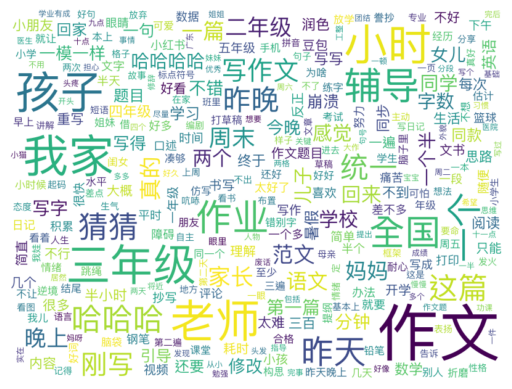

In [36]:
# 根据词袋模型分析结果绘制词云图
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

wordcloud = WordCloud(
    font_path='/System/Library/Fonts/PingFang.ttc',  # 指定中文字体文件路径
    background_color='white',  # 设置背景颜色
    width=800,
    height=600,
    max_words=300,  # 设置最大显示的词数
    max_font_size=100  # 设置字体最大值
).generate_from_frequencies(word_freq)

# 显示词云图
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud_写作辅导.png', dpi=300)
plt.show()

In [15]:
from gensim.test.utils import common_texts
common_texts

[['human', 'interface', 'computer'],
 ['survey', 'user', 'computer', 'system', 'response', 'time'],
 ['eps', 'user', 'interface', 'system'],
 ['system', 'human', 'system', 'eps'],
 ['user', 'response', 'time'],
 ['trees'],
 ['graph', 'trees'],
 ['graph', 'minors', 'trees'],
 ['graph', 'minors', 'survey']]

In [16]:
corpus=df['note-text分词'].apply(lambda X: X.split()).tolist()#切分词语
for document in corpus[:10]:
    print(document[:20])

['小朋友', '字', '特地', '买', '字', '一页', '稿纸', '作文']
['居然', '铅笔', '写']
['担心', '字数', '水文', '各有', '痛苦']
['写', '老师', '写', '不让', '辅导', '辅导', '写']
['开头', '结尾', '第三段', '意义']
['下午', '脑袋', '炸掉']
['内容', '挺', '有趣', '分段']
['结尾', '心情', '一大截']
['老师', '没说', '字数', '水', '字', '不到']
['字', '写']


In [17]:
#训练词嵌入模型
from gensim.models import Word2Vec
corpus=df['note-text分词'].apply(lambda X: X.split()).tolist()#切分词语
model=Word2Vec(
    corpus, #训练语料
    window=5,#训练算法考虑的当前词语与预测词语在一个句子中的最大距离（窗口大小）
    vector_size=300,#自定义训练向量维度
    min_count=1,#忽略所有总频数低于这个值的词语
    #workers=4,#用于训练的线程数
    epochs=5)#迭代

#保存训练好的模型
model.save('word2vec_写作辅导.model')

In [18]:
word_list=model.wv.index_to_key#获取词汇表
word_vectors=model.wv[word_list]#获取词向量

#打印词汇表和对应的词向量
for word,vector in list(zip(word_list,word_vectors))[:5]:
    print(f'{word}:{vector}'[:20])

写:[ 1.46670686e-03  
作文:[-1.7045365e-03  
字:[ 3.83319170e-03  
我家:[-1.3255542e-03 -
老师:[ 1.7737734e-04  


In [20]:
#检查嵌入模型中任意两个词向量的余弦相似度，即语义接近性
#余弦相似度的取值介于[-1，1]之间，-1表示语义完全相反，1表示语义完全相同，0表示毫无关系
#model.sv.similarity这个函数与np.dot(vector1,vector2)/(np.linalg.norm(vector1)*np.linalg.norm(vector2))输出的结果一样
print(model.wv.similarity('孩子', '作文'))
print(model.wv.similarity('我家', '作文'))
print(model.wv.similarity('老师', '作文'))
print(model.wv.similarity('我家', '孩子'))
print(model.wv.similarity('我家', '老师'))
print(model.wv.similarity('老师', '孩子'))

0.6768693
0.44617447
0.60685974
0.47768643
0.39652547
0.6020598


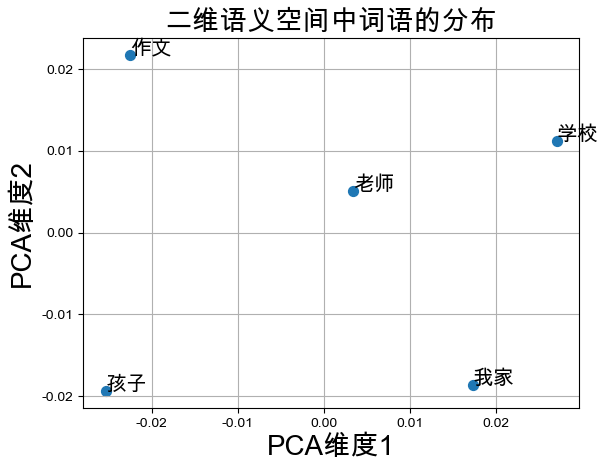

In [21]:
# 可视化

words = ['我家', '孩子', '老师', '作文','学校']
vectors = [model.wv[word] for word in words]

from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

# 使用PCA进行降维
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(vectors)

import matplotlib.pyplot as plt     # 画图

# 绘制四个词语在二维空间的相对位置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.figure()

# 取PCA降维结果中所有行的第一列和第二列数据绘制散点图，设置点的大小为50
plt.scatter(pca_result[:, 0], pca_result[:, 1], s = 50)

for i, word in enumerate(words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize = 15)

plt.xlabel('PCA维度1', fontsize = 20)
plt.ylabel('PCA维度2', fontsize = 20)
plt.title('二维语义空间中词语的分布', fontsize = 20)
plt.grid(True)
plt.show()

In [22]:
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity

from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [23]:
from gensim.models import Word2Vec
txt=df['note-text分词'].apply(lambda X: X.split()).tolist()#切分词语

In [24]:
dictionary = corpora.Dictionary(txt)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in txt]  #表示为第几个单词出现了几次

In [25]:
ldamodel = LdaModel(corpus, num_topics=10, id2word = dictionary, passes=30,random_state = 1)   #分为10个主题
num_topics=10
print(ldamodel.print_topics(num_topics=num_topics, num_words=15)[:20])  #每个主题输出15个单词

[(0, '0.013*"一个" + 0.012*"找" + 0.009*"老师" + 0.009*"只能" + 0.009*"篮球" + 0.009*"拍" + 0.009*"写" + 0.008*"语文" + 0.007*"写作文" + 0.007*"数学" + 0.007*"英语" + 0.007*"二年级" + 0.007*"五年级" + 0.007*"样子" + 0.006*"三年级"'), (1, '0.100*"写" + 0.088*"字" + 0.039*"小时" + 0.018*"我家" + 0.018*"昨天" + 0.017*"刚写" + 0.015*"哈哈哈" + 0.013*"三年级" + 0.013*"一个" + 0.010*"一个半" + 0.009*"作文" + 0.009*"老师" + 0.009*"不错" + 0.008*"晚上" + 0.008*"两个"'), (2, '0.039*"作文" + 0.037*"写" + 0.017*"孩子" + 0.016*"辅导" + 0.015*"老师" + 0.013*"字" + 0.012*"一模一样" + 0.010*"同款" + 0.010*"三年级" + 0.008*"猜猜" + 0.008*"昨天" + 0.008*"家长" + 0.007*"儿子" + 0.007*"这篇" + 0.007*"简直"'), (3, '0.149*"写" + 0.022*"我家" + 0.021*"老师" + 0.018*"作业" + 0.018*"孩子" + 0.016*"三年级" + 0.012*"分钟" + 0.011*"学校" + 0.010*"小时" + 0.008*"写得" + 0.008*"周末" + 0.006*"猜猜" + 0.005*"太难" + 0.005*"抄" + 0.005*"一句"'), (4, '0.034*"作文" + 0.016*"妈妈" + 0.015*"辅导" + 0.012*"写" + 0.008*"孩子" + 0.008*"娃" + 0.007*"作业" + 0.007*"字" + 0.007*"进去" + 0.007*"快" + 0.006*"一篇" + 0.006*"三年级" + 0.006*"阅读" + 0.005*"努力" + 0.005*"修改

In [26]:
#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

In [27]:
#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30,random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=txt, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

[(0, '0.067*"写" + 0.022*"作文" + 0.017*"字" + 0.011*"我家" + 0.010*"老师" + 0.010*"孩子" + 0.010*"小时" + 0.010*"三年级" + 0.007*"辅导" + 0.007*"作业"')]
0.27157442020857675
[(0, '0.027*"作文" + 0.016*"辅导" + 0.014*"抄" + 0.009*"写" + 0.007*"统一" + 0.007*"全国" + 0.007*"妈妈" + 0.006*"猜猜" + 0.006*"孩子" + 0.005*"哈哈哈哈"'), (1, '0.102*"写" + 0.028*"字" + 0.019*"作文" + 0.016*"小时" + 0.015*"我家" + 0.014*"老师" + 0.014*"三年级" + 0.013*"孩子" + 0.010*"作业" + 0.009*"昨天"')]
0.3418993384416744
[(0, '0.014*"抄" + 0.009*"作文" + 0.007*"一个" + 0.007*"写得" + 0.006*"妈妈" + 0.006*"找" + 0.005*"同步" + 0.004*"数学" + 0.004*"写作文" + 0.004*"写成"'), (1, '0.103*"写" + 0.036*"字" + 0.025*"小时" + 0.017*"我家" + 0.013*"老师" + 0.010*"哈哈哈" + 0.009*"刚写" + 0.008*"一个" + 0.008*"作业" + 0.007*"娃"'), (2, '0.067*"写" + 0.046*"作文" + 0.019*"三年级" + 0.019*"孩子" + 0.017*"辅导" + 0.016*"全国" + 0.011*"老师" + 0.011*"统一" + 0.010*"猜猜" + 0.009*"这篇"')]
0.33865661728866786
[(0, '0.012*"抄" + 0.009*"作文" + 0.008*"同步" + 0.007*"一个" + 0.007*"找" + 0.005*"妈妈" + 0.005*"哈哈哈哈" + 0.005*"数学" + 0.005*"老师" + 0.00

0.3787353072328299
[(0, '0.016*"作文题目" + 0.014*"老师" + 0.011*"找" + 0.010*"篮球" + 0.009*"小时" + 0.009*"作文" + 0.009*"写" + 0.009*"作业" + 0.008*"辅导" + 0.008*"只能"'), (1, '0.082*"字" + 0.066*"写" + 0.017*"哈哈哈" + 0.014*"老师" + 0.012*"猜猜" + 0.012*"小时" + 0.009*"学校" + 0.009*"生活" + 0.008*"孩子" + 0.008*"一个"'), (2, '0.076*"写" + 0.032*"昨天" + 0.032*"辅导" + 0.027*"作文" + 0.021*"老师" + 0.017*"娃" + 0.015*"孩子" + 0.011*"家长" + 0.011*"字" + 0.009*"一个"'), (3, '0.085*"写" + 0.025*"作业" + 0.023*"孩子" + 0.018*"三年级" + 0.015*"老师" + 0.013*"写得" + 0.010*"猜猜" + 0.009*"我家" + 0.009*"太难" + 0.008*"作文"'), (4, '0.041*"写" + 0.020*"作文" + 0.015*"老师" + 0.011*"辅导" + 0.010*"孩子" + 0.009*"字" + 0.009*"豆包" + 0.009*"不错" + 0.008*"语文" + 0.008*"情绪"'), (5, '0.023*"哈哈哈" + 0.017*"辅导" + 0.016*"哈哈哈哈" + 0.014*"理解" + 0.014*"一模一样" + 0.011*"作文" + 0.009*"逆境" + 0.009*"同步" + 0.008*"孩子" + 0.007*"答"'), (6, '0.040*"写" + 0.019*"同款" + 0.016*"作文" + 0.016*"分钟" + 0.013*"我家" + 0.012*"笑" + 0.009*"妈妈" + 0.009*"死" + 0.008*"学校" + 0.008*"老师"'), (7, '0.059*"写" + 0.041*"作文" + 0.0

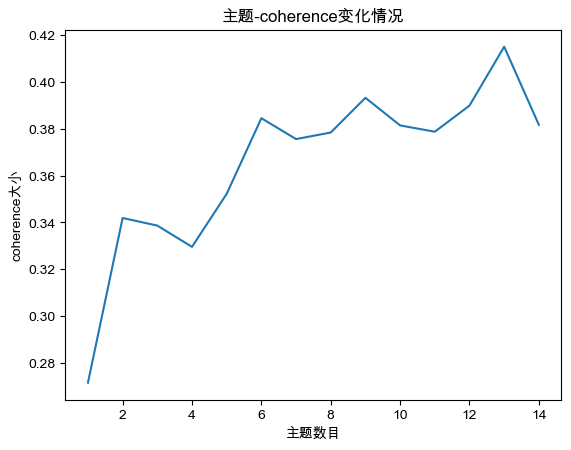

In [28]:
# 绘制困惑度折线图
x = range(1,15)
# z = [perplexity(i) for i in x]
y = [coherence(i) for i in x]
plt.plot(x, y)
plt.xlabel('主题数目')
plt.ylabel('coherence大小')
plt.rcParams['font.sans-serif']=['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus']=False
plt.title('主题-coherence变化情况')
plt.show()

In [29]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes = 30,random_state=1)
topic_list=lda.print_topics()
print(topic_list[:20])

[(0, '0.013*"一个" + 0.009*"作文" + 0.007*"同步" + 0.005*"老师" + 0.005*"逆境" + 0.005*"只能" + 0.005*"找" + 0.004*"英语" + 0.004*"小红书" + 0.004*"抄"'), (1, '0.071*"写" + 0.060*"字" + 0.038*"小时" + 0.013*"一个" + 0.010*"我家" + 0.010*"哈哈哈" + 0.010*"回来" + 0.008*"老师" + 0.008*"三年级" + 0.008*"一个半"'), (2, '0.061*"写" + 0.051*"作文" + 0.027*"全国" + 0.024*"辅导" + 0.024*"三年级" + 0.018*"统一" + 0.015*"昨天" + 0.015*"孩子" + 0.012*"猜猜" + 0.010*"二年级"'), (3, '0.132*"写" + 0.023*"我家" + 0.017*"孩子" + 0.016*"老师" + 0.010*"抄" + 0.010*"作业" + 0.010*"周末" + 0.010*"挺" + 0.008*"作文" + 0.007*"想"'), (4, '0.032*"作文" + 0.024*"写" + 0.014*"抄" + 0.013*"老师" + 0.011*"一篇" + 0.009*"同款" + 0.009*"修改" + 0.008*"辅导" + 0.007*"不错" + 0.007*"孩子"')]


In [30]:
result_list =[]
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    result_list.append(i[bz][0])
print(result_list[:20])

[1, 3, 4, 2, 2, 1, 0, 2, 1, 1, 4, 2, 1, 1, 4, 4, 1, 0, 2, 1]


In [32]:
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(data, '写作辅导.html')